Clustering Routine for Skills Project:Phase 2<br>
Written by: Robert Methven (@methvenr)<br>
Date: April 2025<br>

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import numpy.matlib
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from kmodes.kprototypes import KPrototypes
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import os
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.preprocessing import OneHotEncoder
from scipy.spatial.distance import cdist
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Create output directories if they don't exist
if not os.path.exists('cluster_outputs'):
    os.makedirs('cluster_outputs')

# Load sample sales data (replace this with your actual data import)
filename = "DGR.xlsx"

string_part = filename[filename.find('"')+1:filename.rfind('.')]

df = pd.read_excel(filename)

# rename revenue and sales cycle columns
df = df.rename(columns={
    'pipelineannualizedrevenue$': 'avg_revenue',
    'avg_sales_cycle_duration': 'avg_cycle'
})

# Define numerical and categorical columns
numerical_features =  ['opp_new_valid', 'opp_closed', 'win_rate', 'lead_conversion_rate','avg_revenue','avg_cycle']
categorical_features = ['tenure','segment', 'geo']

In [123]:
# 1. Data Preprocessing
print("Missing values in dataset:")
print(df.isnull().sum())

# Handle missing values
# For numerical features
df[numerical_features] = df[numerical_features].fillna(df[numerical_features].median())
# For categorical features
for cat_col in categorical_features:
    df[cat_col] = df[cat_col].fillna(df[cat_col].mode()[0])

Missing values in dataset:
emplid                  0
tenure                  0
segment                 4
geo                     0
opp_new_valid           0
opp_closed              0
win_rate                0
lead_conversion_rate    0
avg_revenue             0
avg_cycle               0
dtype: int64


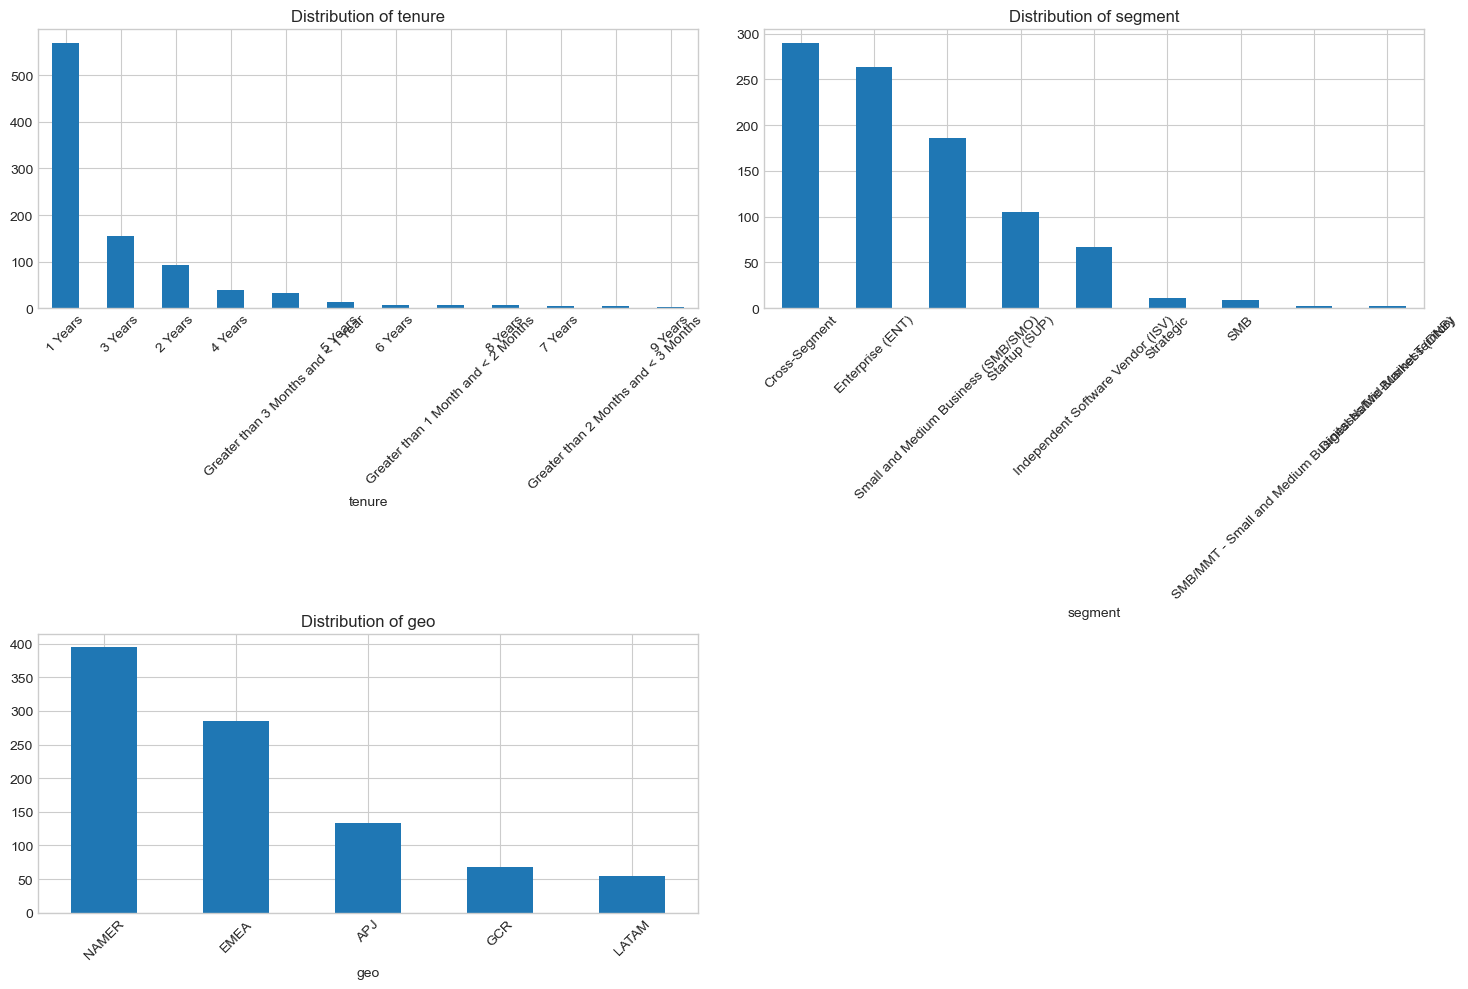

In [124]:
# 2. Analyze categorical variables
plt.figure(figsize=(15, 10))
for idx, cat_col in enumerate(categorical_features, 1):
    plt.subplot(2, 2, idx)
    df[cat_col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {cat_col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('cluster_outputs/categorical_distributions.png')
#plt.close()

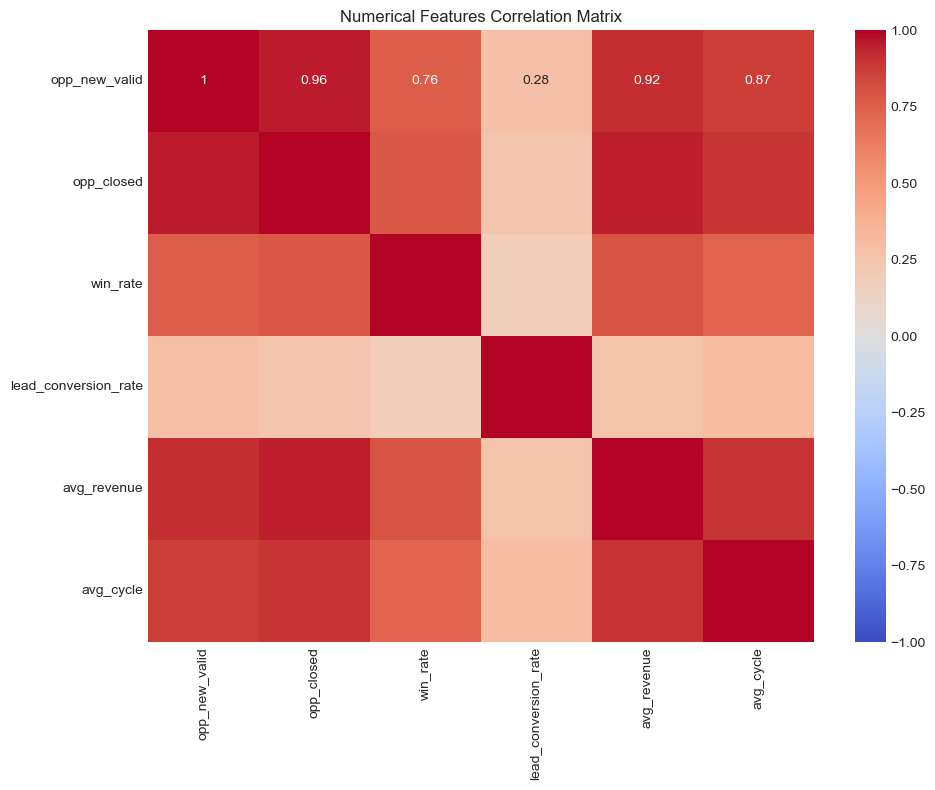

In [125]:
# 3. Test for multicollinearity in numerical features
correlation_matrix = df[numerical_features].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Numerical Features Correlation Matrix')
plt.tight_layout()
plt.savefig('cluster_outputs/correlation_matrix.png')
#plt.close()

In [126]:
# Remove highly correlated numerical features
def remove_correlated_features(correlation_matrix, threshold=0.8):
    features_to_drop = set()
    for i in range(len(correlation_matrix.columns)):
        for j in range(i):
            if abs(correlation_matrix.iloc[i, j]) > threshold:
                features_to_drop.add(correlation_matrix.columns[i])
    return features_to_drop

features_to_drop = remove_correlated_features(correlation_matrix)
final_numerical_features = [f for f in numerical_features if f not in features_to_drop]
print("\nHighly Correlated Features:")
print(features_to_drop)


Highly Correlated Features:
{'avg_cycle', 'opp_closed', 'avg_revenue'}


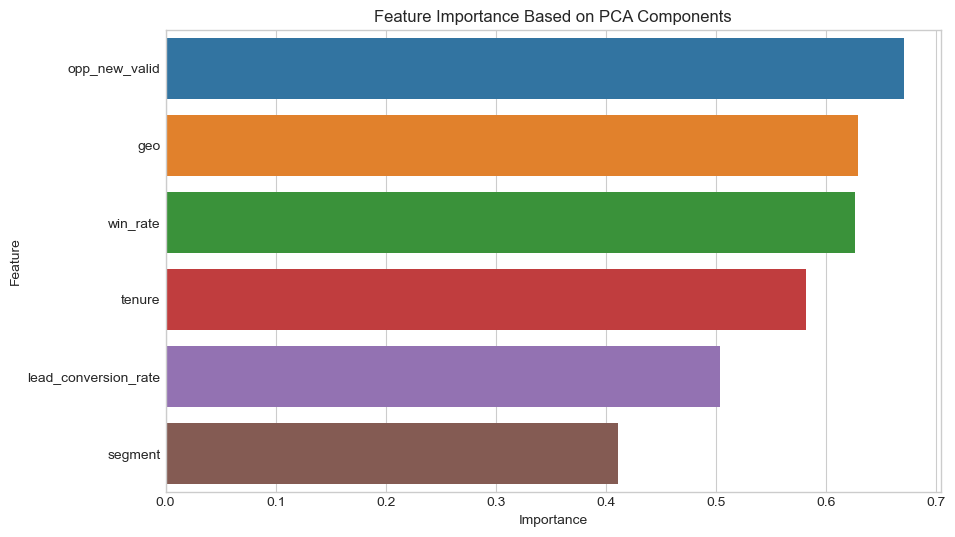


Features sorted by importance:
                                   Feature  Importance
opp_new_valid                opp_new_valid    0.670732
geo                                    geo    0.629139
win_rate                          win_rate    0.626849
tenure                              tenure    0.581574
lead_conversion_rate  lead_conversion_rate    0.504190
segment                            segment    0.411008

Selected important features:
['opp_new_valid', 'geo', 'win_rate', 'tenure']


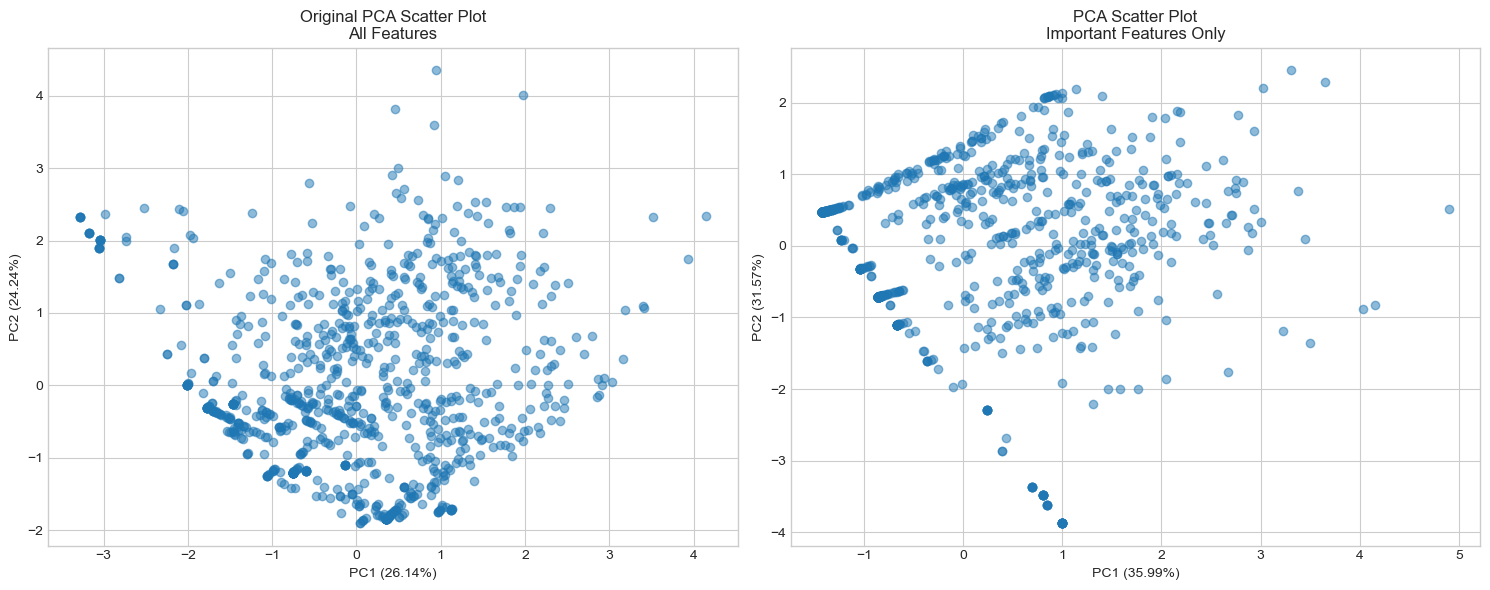


Original explained variance ratio: [0.26142126 0.24237913]
New explained variance ratio: [0.35992296 0.31569875]


In [127]:
# Prepare data for PCA
df_numeric = df[final_numerical_features].copy()
df_categorical = df[categorical_features].copy()

# Handle missing values
df_numeric.fillna(df_numeric.mean(), inplace=True)
df_categorical.fillna(df_categorical.mode().iloc[0], inplace=True)

# Encode categorical variables
label_encoders = {}
for cat_feature in categorical_features:
    label_encoders[cat_feature] = LabelEncoder()
    df_categorical[cat_feature] = label_encoders[cat_feature].fit_transform(df_categorical[cat_feature])

# Combine numerical and encoded categorical features
X = pd.concat([df_numeric, df_categorical], axis=1)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame with PCA results
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

# Calculate feature importance
components_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=final_numerical_features + categorical_features
)

# Calculate absolute importance scores for each feature
feature_importance = pd.DataFrame({
    'Feature': components_df.index,
    'Importance': np.sqrt(components_df['PC1']**2 + components_df['PC2']**2)
})

# Sort features by importance
feature_importance = feature_importance.sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance Based on PCA Components')
plt.show()

# Define importance threshold (you can adjust this)
importance_threshold = feature_importance['Importance'].mean()
#importance_threshold = feature_importance['Importance'].median()
#importance_threshold = feature_importance['Importance'].quantile(0.25)

# Get important features
important_features = feature_importance[feature_importance['Importance'] > importance_threshold]['Feature'].tolist()

print("\nFeatures sorted by importance:")
print(feature_importance)

print("\nSelected important features:")
print(important_features)

# Create new dataset with only important features
important_numerical_features = [f for f in numerical_features if f in important_features]
important_categorical_features = [f for f in categorical_features if f in important_features]

# Prepare new dataset with only important features
df_numeric_important = df[important_numerical_features].copy()
df_categorical_important = df[important_categorical_features].copy()

# Handle missing values
df_numeric_important.fillna(df_numeric_important.mean(), inplace=True)
if len(important_categorical_features) > 0:
    df_categorical_important.fillna(df_categorical_important.mode().iloc[0], inplace=True)
    
    # Encode categorical variables
    label_encoders_important = {}
    for cat_feature in important_categorical_features:
        label_encoders_important[cat_feature] = LabelEncoder()
        df_categorical_important[cat_feature] = label_encoders_important[cat_feature].fit_transform(df_categorical_important[cat_feature])
    
    # Combine numerical and encoded categorical features
    X_important = pd.concat([df_numeric_important, df_categorical_important], axis=1)
else:
    X_important = df_numeric_important

# Scale the important features
scaler_important = StandardScaler()
X_scaled_important = scaler_important.fit_transform(X_important)

# Apply PCA on important features
pca_important = PCA(n_components=2)
X_pca_important = pca_important.fit_transform(X_scaled_important)

# Create DataFrame with new PCA results
pca_df_important = pd.DataFrame(
    X_pca_important,
    columns=['PC1', 'PC2']
)

# Calculate new explained variance ratio
explained_variance_ratio_important = pca_important.explained_variance_ratio_
cumulative_variance_ratio_important = np.cumsum(explained_variance_ratio_important)

# Compare original vs reduced feature set
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Original PCA scatter plot
ax1.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.5)
ax1.set_title('Original PCA Scatter Plot\nAll Features')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax1.grid(True)

# Reduced features PCA scatter plot
ax2.scatter(pca_df_important['PC1'], pca_df_important['PC2'], alpha=0.5)
ax2.set_title('PCA Scatter Plot\nImportant Features Only')
ax2.set_xlabel(f'PC1 ({explained_variance_ratio_important[0]:.2%})')
ax2.set_ylabel(f'PC2 ({explained_variance_ratio_important[1]:.2%})')
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nOriginal explained variance ratio:", pca.explained_variance_ratio_)
print("New explained variance ratio:", explained_variance_ratio_important)


In [128]:
print(important_numerical_features)
print(important_categorical_features)

['opp_new_valid', 'win_rate']
['tenure', 'geo']


In [129]:
def calculate_gap_statistic(data, k_range, categorical_indices, n_refs=5):
    """
    Calculate Gap statistic for optimal k
    """
    gaps = []
    sdk = []
    
    for k in k_range:
        # Reference datasets
        ref_dispersions = []
        for i in range(n_refs):
            # Create random reference dataset
            random_data = np.random.uniform(0, 1, size=data.shape)
            # For categorical columns, use original values
            random_data[:, categorical_indices] = data[:, categorical_indices]
            
            kproto = KPrototypes(n_clusters=k, random_state=42)
            clusters = kproto.fit_predict(random_data, categorical=categorical_indices)
            ref_dispersions.append(np.log(kproto.cost_))
            
        # Actual dataset
        kproto = KPrototypes(n_clusters=k, random_state=42)
        clusters = kproto.fit_predict(data, categorical=categorical_indices)
        actual_dispersion = np.log(kproto.cost_)
        
        # Calculate gap statistic
        gap = np.mean(ref_dispersions) - actual_dispersion
        sd = np.std(ref_dispersions) * np.sqrt(1 + 1/n_refs)
        
        gaps.append(gap)
        sdk.append(sd)
        
    return np.array(gaps), np.array(sdk)

In [130]:
# 4. Prepare data for clustering
# Scale numerical features
scaler = StandardScaler()
X_numerical = scaler.fit_transform(df[important_numerical_features])
#X_numerical = scaler.fit_transform(df[final_numerical_features])

# Encode categorical features
label_encoders = {}
X_categorical = df[important_categorical_features].copy()
#for cat_col in categorical_features:
for cat_col in important_categorical_features:
    label_encoders[cat_col] = LabelEncoder()
    X_categorical[cat_col] = label_encoders[cat_col].fit_transform(X_categorical[cat_col])

# Combine numerical and categorical data
X_combined = np.column_stack([X_numerical, X_categorical])

# Create categorical indices for k-prototypes
categorical_indices = list(range(len(important_numerical_features), 
                               len(important_numerical_features) + len(important_categorical_features)))

# Encode categorical features - old
#label_encoders = {}
#X_categorical = df[categorical_features].copy()
#for cat_col in categorical_features:
#for cat_col in categorical_features:
#    label_encoders[cat_col] = LabelEncoder()
#    X_categorical[cat_col] = label_encoders[cat_col].fit_transform(X_categorical[cat_col])

# Combine numerical and categorical data
#X_combined = np.column_stack([X_numerical, X_categorical])

# Create categorical indices for k-prototypes
#categorical_indices = list(range(len(final_numerical_features), 
#                               len(final_numerical_features) + len(categorical_features)))

# Initialize lists to store metrics
K = range(2, 8)
cost_list = []
silhouette_scores = []
ch_scores = []
gap_scores = []

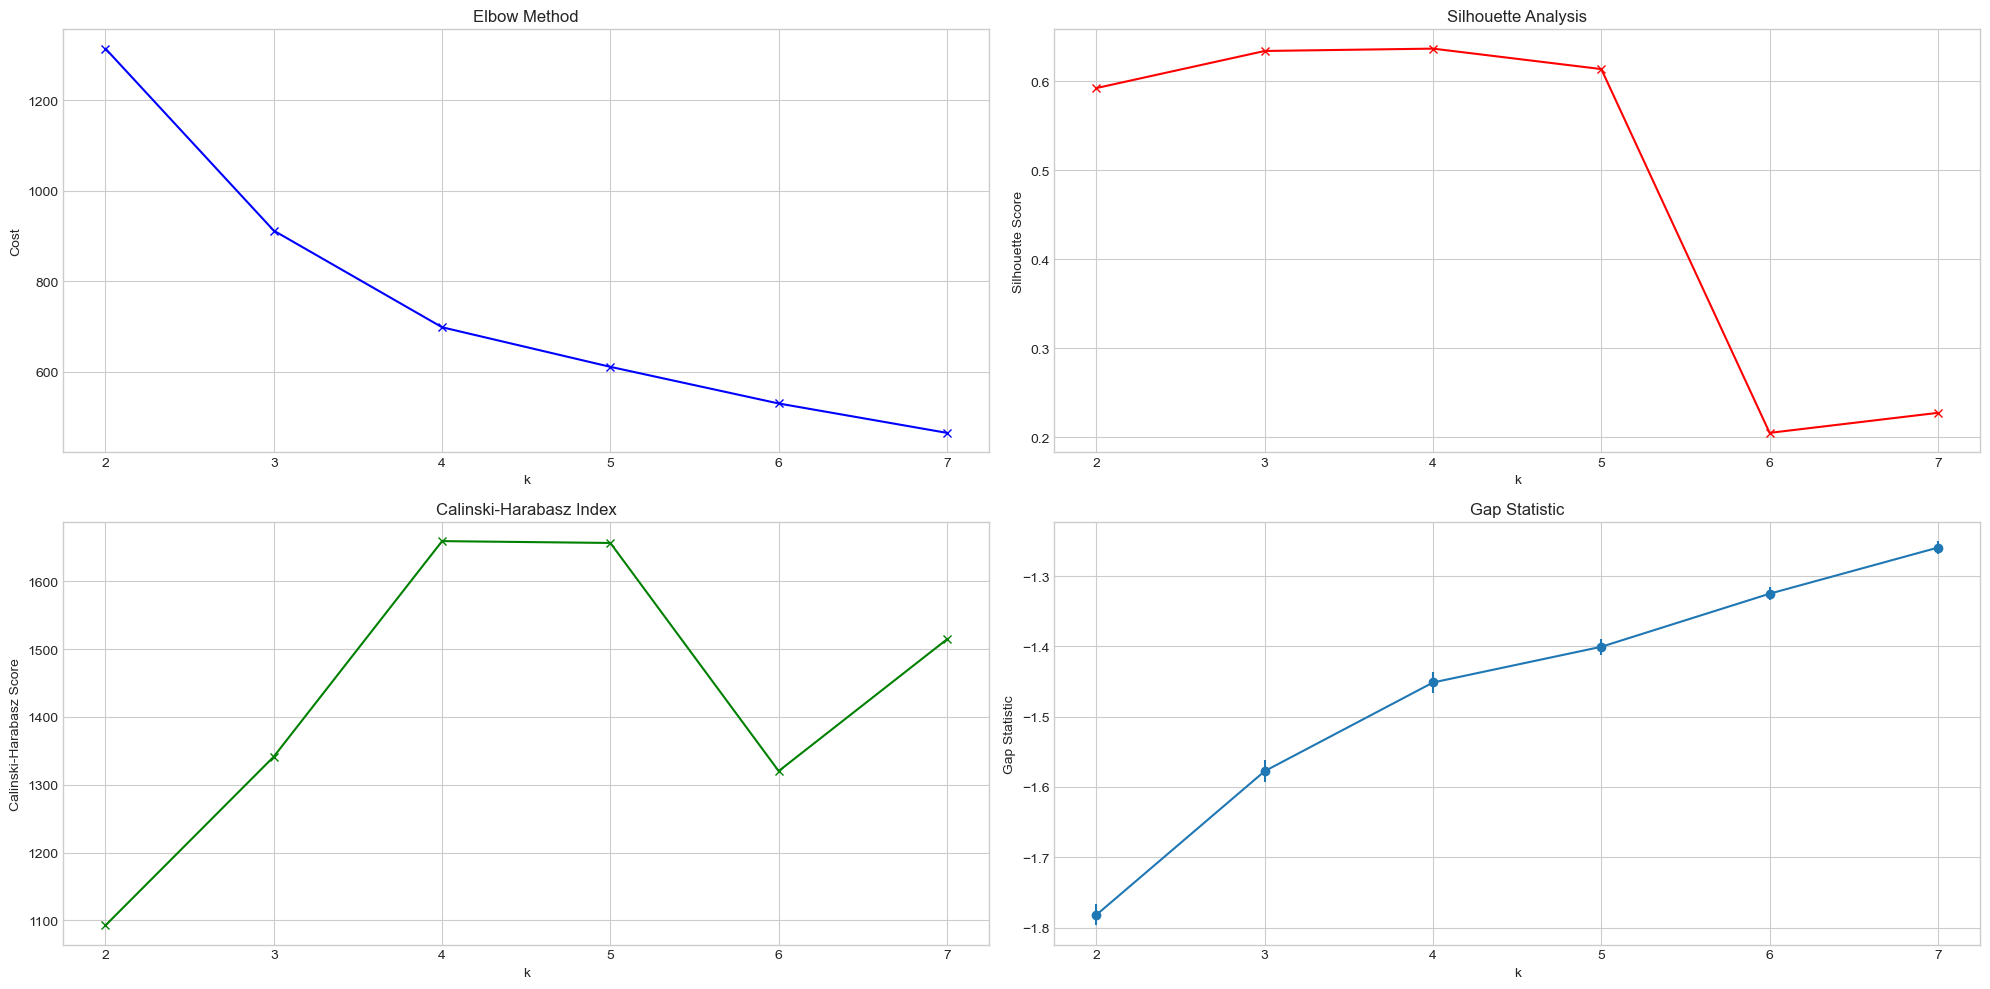

In [131]:
# Calculate metrics for each k
for k in K:
    # Fit k-prototypes
    kproto = KPrototypes(n_clusters=k, random_state=42)
    clusters = kproto.fit_predict(X_combined, categorical=categorical_indices)
    
    # Cost (Within-cluster sum of squares)
    cost_list.append(kproto.cost_)
    
    # Silhouette score (using Gower distance for mixed data)
    # Note: This is a simplified version of silhouette score for mixed data
    silhouette_scores.append(silhouette_score(X_numerical, clusters))
    
    # Calinski-Harabasz score (using only numerical features)
    ch_scores.append(calinski_harabasz_score(X_numerical, clusters))

# Calculate Gap statistic
gaps, s_k = calculate_gap_statistic(X_combined, K, categorical_indices)

# Create visualization of all metrics
plt.figure(figsize=(20, 10))

# Elbow curve
plt.subplot(2, 2, 1)
plt.plot(K, cost_list, 'bx-')
plt.xlabel('k')
plt.ylabel('Cost')
plt.title('Elbow Method')

# Silhouette score
plt.subplot(2, 2, 2)
plt.plot(K, silhouette_scores, 'rx-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')

# Calinski-Harabasz score
plt.subplot(2, 2, 3)
plt.plot(K, ch_scores, 'gx-')
plt.xlabel('k')
plt.ylabel('Calinski-Harabasz Score')
plt.title('Calinski-Harabasz Index')

# Gap statistic
plt.subplot(2, 2, 4)
plt.errorbar(K, gaps, yerr=s_k, fmt='o-')
plt.xlabel('k')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic')

plt.tight_layout()
plt.savefig('cluster_outputs/optimal_k_analysis.png')
#plt.close()

In [132]:
# Determine optimal k using different methods
def find_elbow(costs):
    """Find the elbow point using the maximum curvature method"""
    nPoints = len(costs)
    allCoord = np.vstack((range(nPoints), costs)).T
    firstPoint = allCoord[0]
    lineVec = allCoord[-1] - allCoord[0]
    lineVecNorm = lineVec / np.sqrt(np.sum(lineVec**2))
    vecFromFirst = allCoord - firstPoint
    scalarProduct = np.sum(vecFromFirst * np.matlib.repmat(lineVecNorm, nPoints, 1), axis=1)
    vecFromFirstParallel = np.outer(scalarProduct, lineVecNorm)
    vecToLine = vecFromFirst - vecFromFirstParallel
    distToLine = np.sqrt(np.sum(vecToLine ** 2, axis=1))
    return np.argmax(distToLine) + 2  # +2 because K starts at 2

In [133]:
def find_optimal_k():
    # Elbow method
    k_elbow = find_elbow(cost_list)
    
    # Silhouette score
    k_silhouette = K[np.argmax(silhouette_scores)]
    
    # Calinski-Harabasz score
    k_ch = K[np.argmax(ch_scores)]
    
    # Gap statistic
    k_gap = K[np.argmax(gaps)]
    
    return {
        'Elbow Method': k_elbow,
        'Silhouette Score': k_silhouette,
        'Calinski-Harabasz': k_ch,
        'Gap Statistic': k_gap
    }

optimal_k_results = find_optimal_k()

In [134]:
# Create a summary DataFrame of optimal k results
optimal_k_df = pd.DataFrame.from_dict(optimal_k_results, orient='index', columns=['Optimal k'])

# Export results
optimal_k_df.to_excel(f'cluster_outputs/optimal_k_results{string_part}.xlsx')

# Print results
print("\nOptimal number of clusters according to different methods:")
print(optimal_k_df)

# Calculate consensus optimal k (mode of all methods)
consensus_k = int(optimal_k_df.mode().iloc[0])
print(f"\nConsensus optimal number of clusters: {consensus_k}")

# Use consensus k for final clustering
final_kproto = KPrototypes(n_clusters=consensus_k, random_state=42)
df['Cluster'] = final_kproto.fit_predict(X_combined, categorical=categorical_indices)

# [Continue with the rest of the analysis using the consensus optimal k]

# Additional validation metrics for the chosen k
final_metrics = {
    'Cost': final_kproto.cost_,
    'Silhouette Score': silhouette_score(X_numerical, df['Cluster']),
    'Calinski-Harabasz Score': calinski_harabasz_score(X_numerical, df['Cluster'])
}

# Export final validation metrics
pd.DataFrame.from_dict(final_metrics, orient='index', columns=['Value']).to_excel(
    f'cluster_outputs/final_cluster_validation_metrics{string_part}.xlsx'
)

print("\nFinal Clustering Validation Metrics:")
for metric, value in final_metrics.items():
    print(f"{metric}: {value:.4f}")


Optimal number of clusters according to different methods:
                   Optimal k
Elbow Method               4
Silhouette Score           4
Calinski-Harabasz          4
Gap Statistic              7

Consensus optimal number of clusters: 4

Final Clustering Validation Metrics:
Cost: 698.1557
Silhouette Score: 0.6367
Calinski-Harabasz Score: 1659.1630


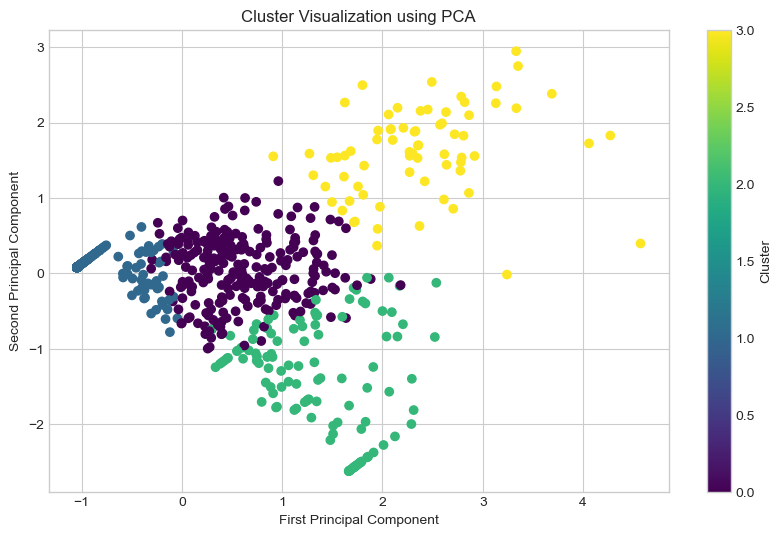

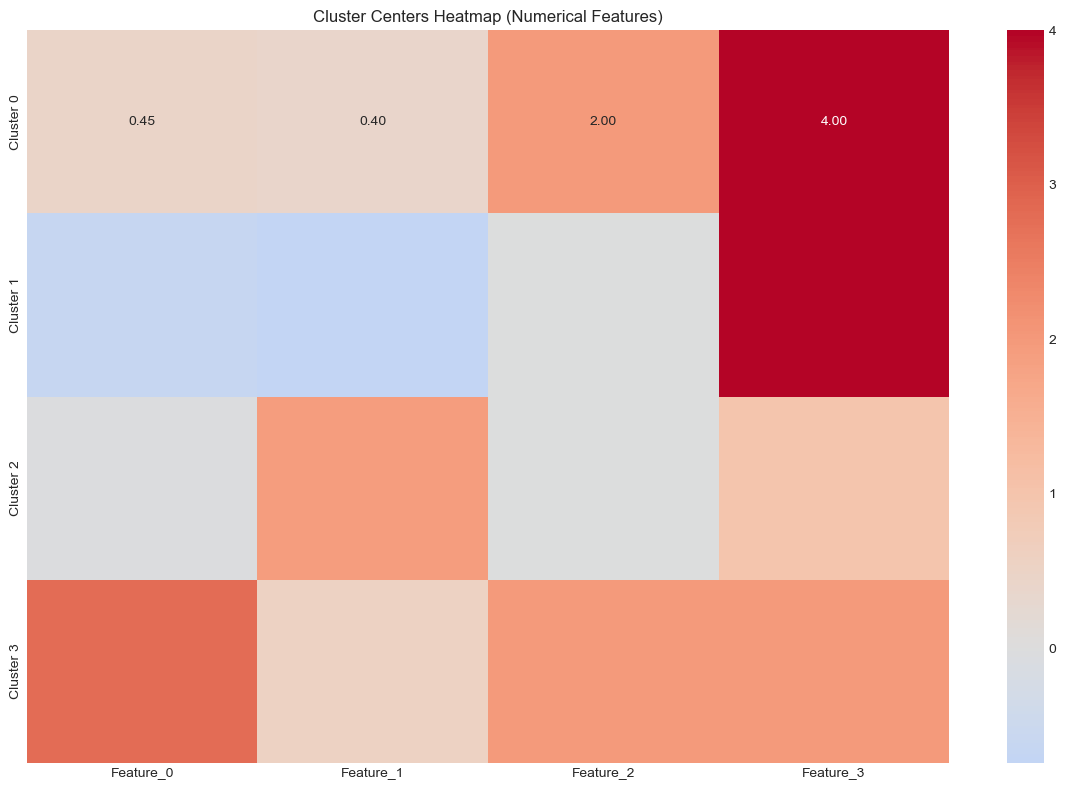

<Figure size 1000x600 with 0 Axes>

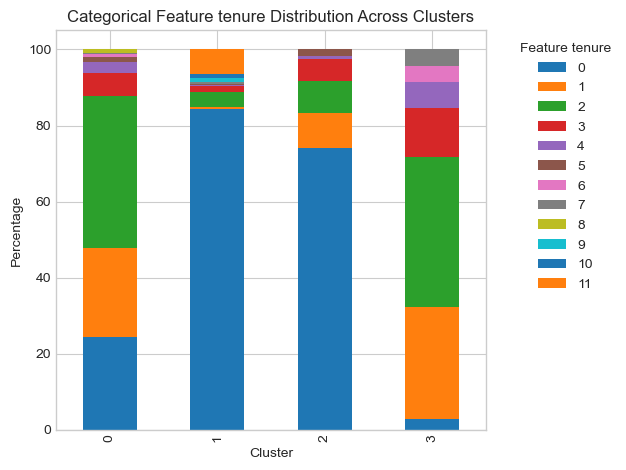

<Figure size 1000x600 with 0 Axes>

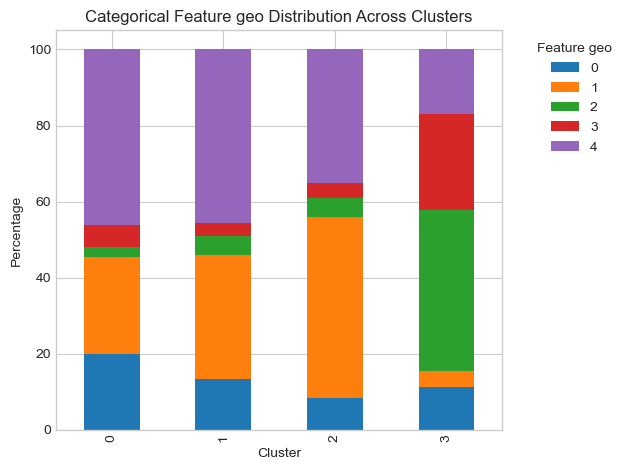

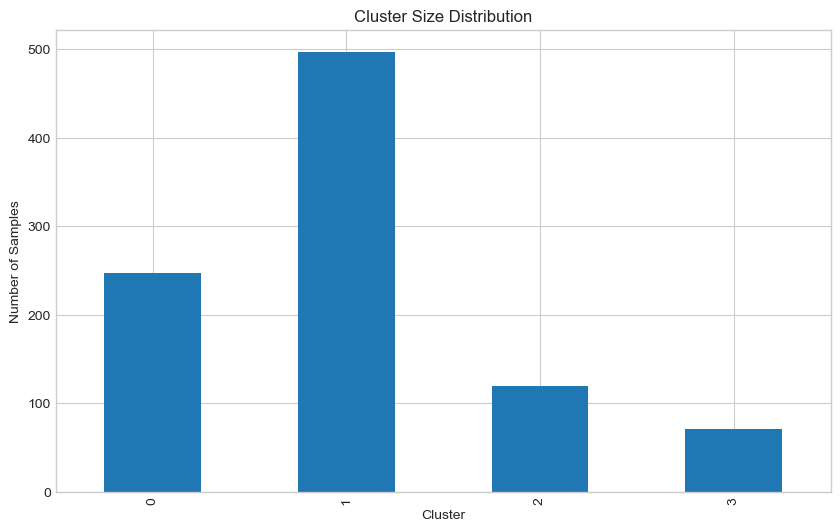

In [135]:
# === VISUALIZATION CODE ===
# Set the style
plt.style.use('seaborn-v0_8-whitegrid')

# 1. PCA Visualization (for numerical features)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_numerical)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis')
plt.title('Cluster Visualization using PCA')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.colorbar(scatter, label='Cluster')
plt.savefig(f'cluster_outputs/cluster_pca_visualization{string_part}.png')
#plt.close()

# 2. Heatmap of Cluster Centers (for numerical features)
centroids = final_kproto.cluster_centroids_

# Check if centroids is a list or tuple
if isinstance(centroids, (list, tuple)):
    numerical_centroids = centroids[0]  # Assuming the first element contains numerical centroids
else:
    numerical_centroids = centroids  # If it's not a list/tuple, use it directly

num_clusters, num_features = numerical_centroids.shape

# Ensure we have the correct number of column names
if len(numerical_columns) != num_features:
    numerical_columns = [f'Feature_{i}' for i in range(num_features)]

cluster_centers_df = pd.DataFrame(
    numerical_centroids,
    columns=numerical_columns,
    index=[f'Cluster {i}' for i in range(num_clusters)]
)

plt.figure(figsize=(max(12, num_features * 0.5), max(8, num_clusters * 0.5)))
sns.heatmap(cluster_centers_df, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Cluster Centers Heatmap (Numerical Features)')
plt.tight_layout()
plt.savefig(f'cluster_outputs/cluster_centers_heatmap{string_part}.png')
#plt.close()

# 3. Categorical Features Distribution
categorical_columns = X_categorical.columns if hasattr(X_categorical, 'columns') else [f'Cat_{i}' for i in range(X_categorical.shape[1])]
for idx, cat_col in enumerate(categorical_columns):
    plt.figure(figsize=(10, 6))
    if isinstance(X_categorical, pd.DataFrame):
        cat_data = X_categorical[cat_col]
    else:
        cat_data = X_categorical[:, idx]
    
    df_cat_dist = pd.crosstab(df['Cluster'], cat_data, normalize='index') * 100
    df_cat_dist.plot(kind='bar', stacked=True)
    plt.title(f'Categorical Feature {cat_col} Distribution Across Clusters')
    plt.xlabel('Cluster')
    plt.ylabel('Percentage')
    plt.legend(title=f'Feature {cat_col}', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f'cluster_outputs/categorical_feature_{idx}_distribution{string_part}.png')
   #plt.close()

# 4. Cluster Size Distribution
plt.figure(figsize=(10, 6))
df['Cluster'].value_counts().sort_index().plot(kind='bar')
plt.title('Cluster Size Distribution')
plt.xlabel('Cluster')
plt.ylabel('Number of Samples')
plt.savefig(f'cluster_outputs/cluster_size_distribution{string_part}.png')
#plt.close()



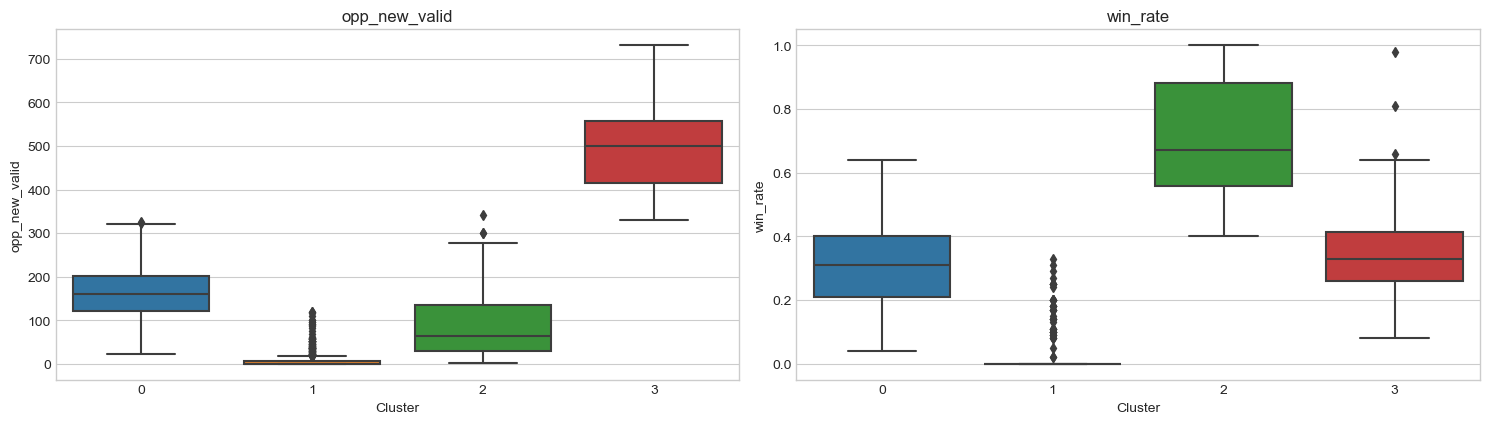

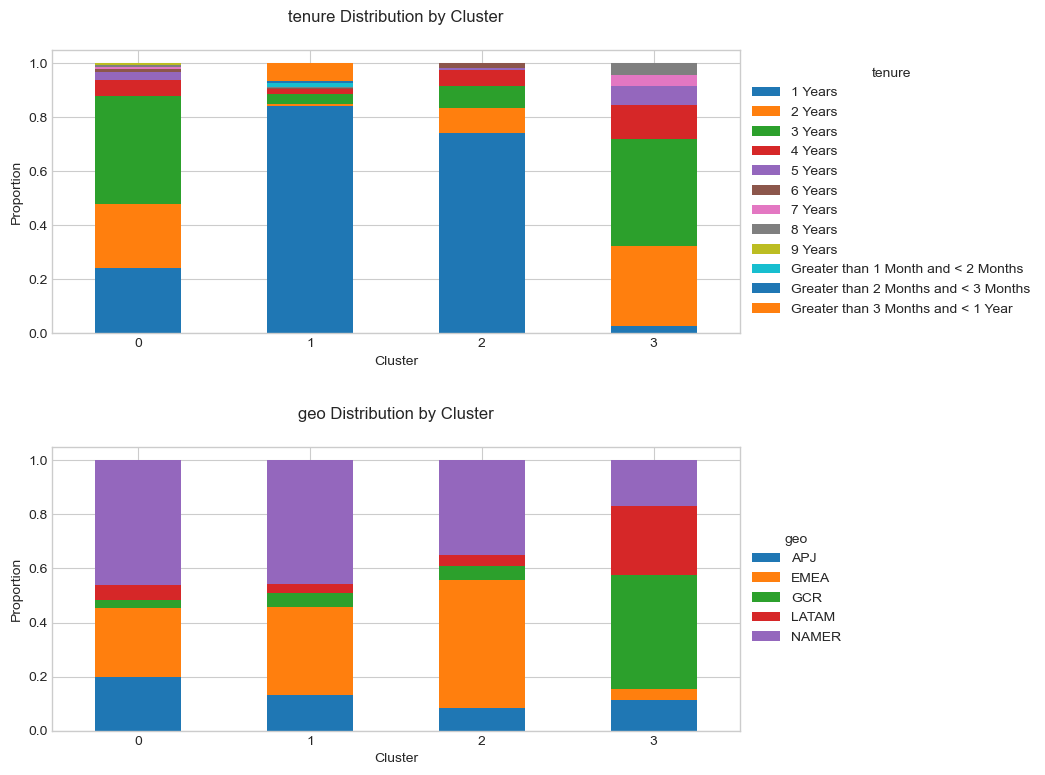

In [136]:
# 6. Analyze clusters
# Numerical features analysis
plt.figure(figsize=(15, 8))
for i, feature in enumerate(important_numerical_features):
    plt.subplot(2, (len(final_numerical_features)+1)//2, i+1)
    sns.boxplot(x='Cluster', y=feature, data=df)
    plt.title(feature)
plt.tight_layout()
plt.savefig(f'cluster_outputs/numerical_features_by_cluster{string_part}.png')
#plt.close()

# Categorical features analysis
fig = plt.figure(figsize=(12, 14))  # Increased height to accommodate gaps

# Create GridSpec with 3 rows and 4 columns with vertical spacing
gs = fig.add_gridspec(3, 4, hspace=0.4)  # Added hspace for vertical gaps

for i, feature in enumerate(important_categorical_features):
    # Use 3 columns for plot, 1 for legend
    ax = fig.add_subplot(gs[i, :3])  # Plot uses first 3 columns
    crosstab = pd.crosstab(df['Cluster'], df[feature], normalize='index')
    crosstab.plot(kind='bar', stacked=True, ax=ax)
    ax.set_title(f'{feature} Distribution by Cluster', pad=20)  # Added padding below title
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=0)
    
    # Place legend in the 4th column
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels,
             title=feature,
             bbox_to_anchor=(1, 0.5),
             loc='center left')

# Save and show the plot
plt.savefig(f'cluster_outputs/numerical_features_by_cluster{string_part}.png', 
            bbox_inches='tight',
            dpi=300,
            pad_inches=0.5)  # Added padding around the entire figure
plt.show()
#plt.close()

In [137]:
# 7. Calculate cluster profiles
numerical_profiles = df.groupby('Cluster')[final_numerical_features].agg([
    'mean', 'std', 'min', 'max'
]).round(2)

categorical_profiles = {}
for cat_col in categorical_features:
    categorical_profiles[cat_col] = pd.crosstab(
        df['Cluster'], 
        df[cat_col], 
        normalize='index'
    ).round(2)

In [138]:
# 8. Export results
with pd.ExcelWriter(f'cluster_outputs/mixed_clustering_analysis_{string_part}.xlsx') as writer:
    df.to_excel(writer, sheet_name='Clustered_Data', index=False)
    numerical_profiles.to_excel(writer, sheet_name='Numerical_Profiles')
    for cat_col, profile in categorical_profiles.items():
        profile.to_excel(writer, sheet_name=f'{cat_col}_Profile')

In [139]:
# 9. Create cluster summary
cluster_summary = pd.DataFrame()
cluster_summary['Size'] = df['Cluster'].value_counts()
cluster_summary['Percentage'] = (cluster_summary['Size'] / len(df) * 100).round(2)

# Export cluster summary
cluster_summary.to_excel(f'cluster_outputs/cluster_summary_{string_part}.xlsx')

In [140]:
# 10. Print summary statistics
print("\nCluster Sizes:")
print(cluster_summary)

print("\nNumerical Profiles:")
print(numerical_profiles)

print("\nAnalysis Complete! Check the 'cluster_outputs' folder for detailed results.")


Cluster Sizes:
         Size  Percentage
Cluster                  
1         497       53.16
0         247       26.42
2         120       12.83
3          71        7.59

Numerical Profiles:
        opp_new_valid                   win_rate                    \
                 mean     std  min  max     mean   std   min   max   
Cluster                                                              
0              161.40   66.35   23  325     0.31  0.12  0.04  0.64   
1                9.56   20.49    0  119     0.02  0.05  0.00  0.33   
2               92.88   81.36    1  341     0.71  0.19  0.40  1.00   
3              497.75  102.67  331  731     0.35  0.15  0.08  0.98   

        lead_conversion_rate                  
                        mean   std  min  max  
Cluster                                       
0                       0.57  0.37  0.0  1.0  
1                       0.37  0.41  0.0  1.0  
2                       0.41  0.35  0.0  1.0  
3                       0.40  0.33